In [1]:
! pip install python-dotenv
! pip install -U langchain-google-genai

  Using cached python_dotenv-1.1.0-py3-none-any.whl.metadata (24 kB)
Using cached python_dotenv-1.1.0-py3-none-any.whl (20 kB)
  Using cached filetype-1.2.0-py2.py3-none-any.whl.metadata (6.5 kB)
  Using cached langchain_core-0.3.65-py3-none-any.whl.metadata (5.8 kB)
  Using cached pydantic-2.11.7-py3-none-any.whl.metadata (67 kB)
  Using cached protobuf-6.31.1-cp310-abi3-win_amd64.whl.metadata (593 bytes)
  Using cached langsmith-0.3.45-py3-none-any.whl.metadata (15 kB)
  Using cached tenacity-9.1.2-py3-none-any.whl.metadata (1.2 kB)
  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
  Using cached packaging-24.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached orjson-3.10.18-cp311-cp311-win_amd64.whl.metadata (43 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached zstandard-0.23.0-cp311-cp311-win_amd64.whl.metadata (3.0 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()  # Loads from .env

api_key = os.getenv("GOOGLE_API_KEY")
print("API Key loaded:", bool(api_key))  # Just to confirm, prints True if loaded


API Key loaded: True


In [4]:
! pip install -U "langchain[google-genai]"


  Using cached langchain-0.3.25-py3-none-any.whl.metadata (7.8 kB)
  Using cached langchain_text_splitters-0.3.8-py3-none-any.whl.metadata (1.9 kB)
  Using cached sqlalchemy-2.0.41-cp311-cp311-win_amd64.whl.metadata (9.8 kB)
  Using cached greenlet-3.2.3-cp311-cp311-win_amd64.whl.metadata (4.2 kB)
Using cached langchain-0.3.25-py3-none-any.whl (1.0 MB)
Using cached langchain_text_splitters-0.3.8-py3-none-any.whl (32 kB)
Using cached sqlalchemy-2.0.41-cp311-cp311-win_amd64.whl (2.1 MB)
Using cached greenlet-3.2.3-cp311-cp311-win_amd64.whl (297 kB)

   ---------------------------------------- 0/4 [greenlet]
   ---------------------------------------- 0/4 [greenlet]
   ---------------------------------------- 0/4 [greenlet]
   ---------------------------------------- 0/4 [greenlet]
   ---------- ----------------------------- 1/4 [SQLAlchemy]
   ---------- ----------------------------- 1/4 [SQLAlchemy]
   ---------- ----------------------------- 1/4 [SQLAlchemy]
   ---------- -------------

In [5]:
import getpass
import os

if not os.environ.get("GOOGLE_API_KEY"):
  os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter API key for Google Gemini: ")

from langchain.chat_models import init_chat_model

model = init_chat_model("gemini-2.0-flash", model_provider="google_genai")

 ChatModels are instances of LangChain "Runnables", which means they expose a standard interface for interacting with them. To use just simply call the model

In [7]:
from langchain_core.messages import HumanMessage

model.invoke([HumanMessage(content="Hi! I'm Bob")])

AIMessage(content="Hi Bob! It's nice to meet you. How can I help you today?", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--3b0f4422-06a4-462a-8da2-9ccd874bc81d-0', usage_metadata={'input_tokens': 6, 'output_tokens': 19, 'total_tokens': 25, 'input_token_details': {'cache_read': 0}})

In [8]:
model.invoke([HumanMessage(content="What's my name?")]) #The model on its own does not have any concept of state

AIMessage(content="As a large language model, I have no memory of past conversations. Therefore, I don't know your name. You haven't told me!", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--a977f14f-e800-408b-b49e-0da5b5221873-0', usage_metadata={'input_tokens': 6, 'output_tokens': 32, 'total_tokens': 38, 'input_token_details': {'cache_read': 0}})

we need to pass the entire conversation history into the model to take previous converstation into context

In [9]:
from langchain_core.messages import AIMessage

model.invoke(
    [
        HumanMessage(content="Hi! I'm Bob"),
        AIMessage(content="Hello Bob! How can I assist you today?"),
        HumanMessage(content="What's my name?"),
    ]
)

AIMessage(content='Your name is Bob. You told me that at the beginning of our conversation.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--afe55164-57e0-478b-b094-564ee2ba9306-0', usage_metadata={'input_tokens': 22, 'output_tokens': 17, 'total_tokens': 39, 'input_token_details': {'cache_read': 0}})

## Message persistence
builds a LangGraph application that wraps a chat model (like Gemini or GPT) and keeps track of the conversation history across multiple turns, using built-in memory management 

In [11]:
! pip install langgraph

  Using cached xxhash-3.5.0-cp311-cp311-win_amd64.whl.metadata (13 kB)
Using cached xxhash-3.5.0-cp311-cp311-win_amd64.whl (30 kB)

   ------ --------------------------------- 1/6 [ormsgpack]
   ------------- -------------------------- 2/6 [langgraph-sdk]
   -------------------- ------------------- 3/6 [langgraph-checkpoint]
   -------------------- ------------------- 3/6 [langgraph-checkpoint]
   --------------------------------- ------ 5/6 [langgraph]
   --------------------------------- ------ 5/6 [langgraph]
   --------------------------------- ------ 5/6 [langgraph]
   --------------------------------- ------ 5/6 [langgraph]
   --------------------------------- ------ 5/6 [langgraph]
   --------------------------------- ------ 5/6 [langgraph]
   ---------------------------------------- 6/6 [langgraph]



In [ ]:
# uses LangGraph because it’s a better fit for multi-turn conversational apps with message persistence.
from langgraph.checkpoint.memory import MemorySaver

# Import core LangGraph components
from langgraph.graph import START, MessagesState, StateGraph

# Create a new graph workflow with message state schema (to track conversation messages)
workflow = StateGraph(state_schema=MessagesState)


# Define a function that calls the chat model using the current state (conversation history)
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": response}


# Add the 'model' node to the graph with the above call_model function
workflow.add_node("model", call_model)

# Connect the starting point of the graph to the 'model' node
workflow.add_edge(START, "model")
memory = MemorySaver()

# Compile the graph workflow into a runnable app, with message checkpointing enabled
app = workflow.compile(checkpointer=memory)


In [ ]:
config = {"configurable": {"thread_id": "abc123"}} #multiple conversation threads,a common requirement when your application has multiple users

In [14]:
query = "Hi! I'm Bob."

input_messages = [HumanMessage(query)] # This represents the user message to send to the chat app
output = app.invoke({"messages": input_messages}, config)
output["messages"][-1].pretty_print()  # Print the last message (most recent response) nicely formatted

================================== Ai Message ==================================

Hi Bob! It's nice to meet you. How can I help you today?


In [15]:
query = "What's my name?"

input_messages = [HumanMessage(query)]
output = app.invoke({"messages": input_messages}, config)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

Your name is Bob. You just told me!


In [ ]:
config = {"configurable": {"thread_id": "abc234"}} # we can always go back to the original conversation

input_messages = [HumanMessage(query)]
output = app.invoke({"messages": input_messages}, config)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

As a large language model, I have no memory of past conversations. Therefore, I don't know your name. You haven't told me!


In [17]:
config = {"configurable": {"thread_id": "abc123"}}

input_messages = [HumanMessage(query)]
output = app.invoke({"messages": input_messages}, config)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

You told me your name is Bob. Is that correct?


#### This async approach is useful in apps where you might want to handle multiple requests concurrently or integrate with async frameworks.

In [18]:
# Async function for the 'model' node in the graph
async def call_model(state: MessagesState):
    # Await the asynchronous invocation of the model with current messages
    response = await model.ainvoke(state["messages"])
    return {"messages": response}


workflow = StateGraph(state_schema=MessagesState)
workflow.add_edge(START, "model")
workflow.add_node("model", call_model)
app = workflow.compile(checkpointer=MemorySaver())

# Asynchronously invoke the app with input messages and config (e.g., thread ID)
output = await app.ainvoke({"messages": input_messages}, config)

# Pretty print the last message in the conversation (usually the model's reply)
output["messages"][-1].pretty_print()


================================== Ai Message ==================================

As a large language model, I don't have access to personal information. Therefore, I don't know your name.


## What are Prompt Templates?
- A prompt template is a way to structure the input to the language model.

- It takes raw user inputs (like messages) and wraps them with additional instructions or context.

- This helps the LLM understand how to respond, not just what to respond to.

## Why add a system message?
- The system message sets the behavior or persona for the model.

- For example, "You talk like a pirate..." tells the model to respond in a pirate style.

- This guides the entire conversation tone and style

In [19]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder # system message and to pass message in

prompt_template = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You talk like a pirate. Answer all questions to the best of your ability.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

In [20]:
# When calling the model, format the prompt with your conversation messages
formatted_prompt = prompt_template.format_prompt(messages=input_messages)

# Then invoke the model with the formatted prompt messages
response = model.invoke(formatted_prompt.to_messages())
print(response)

content="Ahoy there, matey! I be but a humble parrot, I can't be knowin' yer name unless ye be tellin' it to me, savvy?" additional_kwargs={} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []} id='run--b2911704-042a-4b49-a18f-494c07380dd6-0' usage_metadata={'input_tokens': 22, 'output_tokens': 37, 'total_tokens': 59, 'input_token_details': {'cache_read': 0}}


We can now update our application to incorporate this templat

In [ ]:
# Create the LangGraph workflow with a state schema to hold messages
workflow = StateGraph(state_schema=MessagesState)

# Define the function node that calls the model
def call_model(state: MessagesState):
    # Use the prompt template to format the input state (messages + system message)
    prompt = prompt_template.invoke(state)  

    # Call the model with the formatted prompt
    response = model.invoke(prompt)

    # Return updated state with the model's response
    return {"messages": response}

# Add edges and nodes to the graph workflow
workflow.add_edge(START, "model")
workflow.add_node("model", call_model)

# Initialize memory saver to persist conversation state
memory = MemorySaver()

# Compile the workflow application with persistence
app = workflow.compile(checkpointer=memory)

# Configuration dictionary with a thread_id for context tracking
config = {"configurable": {"thread_id": "abc345"}}

# Prepare the input user message
query = "Hi! I'm Jim."
input_messages = [HumanMessage(query)]

# Invoke the workflow with messages and config
output = app.invoke({"messages": input_messages}, config)

# Pretty-print the last message from the model
output["messages"][-1].pretty_print()


================================== Ai Message ==================================

Ahoy there, Jim! A pleasure to meet ye, me hearty. I be a humble servant o' the digital seas, ready to answer yer questions and share a bit o' pirate wisdom. What be on yer mind today?


In [23]:
query = "What is my name?"

input_messages = [HumanMessage(query)]
output = app.invoke({"messages": input_messages}, config)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

Yer name be Jim, as ye just told me, ye scallywag! Don't be tryin' to trick ol' Cap'n here!


Making  our prompt a little bit more complicated

In [24]:
from typing import Sequence
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from typing_extensions import Annotated, TypedDict


# Define the prompt template with a parameter {language}
prompt_template = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful assistant. Answer all questions to the best of your ability in {language}.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

# Define the state schema for LangGraph
# - messages is a sequence of BaseMessage objects annotated for message addition
# - language is a string parameter passed dynamically to the prompt template
class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    language: str


workflow = StateGraph(state_schema=State)

# Define the node function that calls the model
def call_model(state: State):
    # Format the prompt with dynamic parameters from the state (messages + language)
    prompt = prompt_template.format_prompt(messages=state["messages"], language=state["language"])

    # Convert the prompt to messages before passing it to the model
    response = model.invoke(prompt.to_messages())
    return {"messages": [response]}

# Build the graph structure
workflow.add_edge(START, "model")
workflow.add_node("model", call_model)
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)


In [25]:
config = {"configurable": {"thread_id": "abc456"}}
query = "Hi! I'm Bob."
language = "Spanish"

input_messages = [HumanMessage(query)]
output = app.invoke(
    {"messages": input_messages, "language": language},
    config,
)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

¡Hola, Bob! ¿En qué puedo ayudarte hoy?


In [ ]:
# Note that the entire state is persisted, so we can omit parameters like language if no changes are desired:
query = "What is my name?"

input_messages = [HumanMessage(query)]
output = app.invoke(
    {"messages": input_messages},
    config,
)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

Tu nombre es Bob.


### Managing Conversation History in Chatbots
- When building chatbots with Large Language Models (LLMs), managing conversation history is crucial because:

- The message list grows continuously with every user and AI interaction.

- LLMs have a limited context window — a maximum number of tokens they can process at once.

- If too many messages are sent, the model might overflow its context window, causing errors or loss of important context.

## How to Handle This?
- We want to limit the number of tokens in the message history sent to the LLM:

- This trimming happens after loading previous messages (from memory or session state).

- It happens before formatting the prompt — so the prompt stays within the token limit.

In [27]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, trim_messages

# Create a trimmer function with specified parameters
trimmer = trim_messages(
    max_tokens=65,        # Limit total tokens to 65
    strategy="last",      # Keep last messages (most recent context)
    token_counter=model,  # Use the model to count tokens
    include_system=True,  # Always include the system message (context/instructions)
    allow_partial=False,  # Do not allow partial messages, keep complete ones only
    start_on="human",     # Start trimming at human messages (better context flow)
)

# Example conversation history
messages = [
    SystemMessage(content="you're a good assistant"),   # system instruction
    HumanMessage(content="hi! I'm Bob"),
    AIMessage(content="hi!"),
    HumanMessage(content="I like vanilla ice cream"),
    AIMessage(content="nice"),
    HumanMessage(content="whats 2 + 2"),
    AIMessage(content="4"),
    HumanMessage(content="thanks"),
    AIMessage(content="no problem!"),
    HumanMessage(content="having fun?"),
    AIMessage(content="yes!"),
]

# Use the trimmer to reduce the messages list to fit max_tokens constraint
trimmed_messages = trimmer.invoke(messages)

# Now trimmed_messages contains a subset that fits within token limit


In [28]:
workflow = StateGraph(state_schema=State)


def call_model(state: State):
    trimmed_messages = trimmer.invoke(state["messages"]) # run the trimmer before we pass the messages input to our prompt.
    prompt = prompt_template.invoke(
        {"messages": trimmed_messages, "language": state["language"]}
    )
    response = model.invoke(prompt)
    return {"messages": [response]}


workflow.add_edge(START, "model")
workflow.add_node("model", call_model)

memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

In [29]:
config = {"configurable": {"thread_id": "abc567"}}
query = "What is my name?"
language = "English"

input_messages = messages + [HumanMessage(query)]
output = app.invoke(
    {"messages": input_messages, "language": language},
    config,
)
output["messages"][-1].pretty_print() # wont know since we trimmed it

================================== Ai Message ==================================

As a large language model, I have no memory of past conversations and therefore don't know your name. You haven't told me your name.


In [30]:
config = {"configurable": {"thread_id": "abc678"}}
query = "What math problem did I ask?"
language = "English"

input_messages = messages + [HumanMessage(query)]
output = app.invoke(
    {"messages": input_messages, "language": language},
    config,
)
output["messages"][-1].pretty_print() # but knows because within last information

================================== Ai Message ==================================

You asked "what's 2 + 2".


## What is Streaming?
When you interact with an LLM-based chatbot, the response might take a few seconds to generate. Instead of waiting for the entire answer to finish, streaming lets the model send tokens (words or pieces of words) as soon as they are generated, improving the user experience by showing progress live.



In [31]:
config = {"configurable": {"thread_id": "abc789"}}
query = "Hi I'm Todd, please tell me a joke."
language = "English"

input_messages = [HumanMessage(query)]

# Stream the response tokens as they are generated
for chunk, metadata in app.stream(
    {"messages": input_messages, "language": language},  # inputs
    config,                                              # config
    stream_mode="messages",                              # stream tokens instead of whole response
):
    if isinstance(chunk, AIMessage):  # Only process chunks from the model
        print(chunk.content, end="|") # Print tokens continuously separated by '|'


Hi| Todd! Here's a joke for you:

Why don't scientists trust atoms|?

Because they make up everything!
|

## Why is this useful?
- Users see the answer gradually instead of waiting silently.

- Mimics natural typing or speaking, improving engagement.

- Useful for real-time applications like chatbots or voice assistants.

#### Langgraph
Create a StateGraph

In [59]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages


class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

In [60]:
! pip install -U "langchain[openai]"

In [61]:
from dotenv import load_dotenv
import os

load_dotenv()  # Loads from .env

api_key = os.getenv("GOOGLE_API_KEY")
print("API Key loaded:", bool(api_key))  # Just to confirm, prints True if loaded


API Key loaded: True


In [ ]:

llm = init_chat_model("gemini-2.0-flash", model_provider="google_genai")


def chatbot(state: State): # incorporate the chat model into a simple node
    return {"messages": [llm.invoke(state["messages"])]}


# The first argument is the unique node name
# The second argument is the function or object that will be called whenever
# the node is used.
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph = graph_builder.compile()

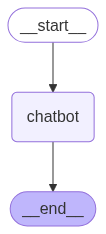

In [64]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [65]:
# run the chatbot
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)


while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

Assistant: Why don't scientists trust atoms?

Because they make up everything!
Goodbye!


## Add tools
##### To handle queries your chatbot can't answer "from memory"so integrate a web search tool. The chatbot can use this tool to find relevant information and provide better responses.

In [66]:
! pip install -U langchain-tavily

  Using cached aiohttp-3.12.13-cp311-cp311-win_amd64.whl.metadata (7.9 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.3.2-py2.py3-none-any.whl.metadata (3.8 kB)
  Using cached frozenlist-1.7.0-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached propcache-0.3.2-cp311-cp311-win_amd64.whl.metadata (12 kB)
  Using cached yarl-1.20.1-cp311-cp311-win_amd64.whl.metadata (76 kB)
  Using cached mypy_extensions-1.1.0-py3-none-any.whl.metadata (1.1 kB)
Using cached aiohttp-3.12.13-cp311-cp311-win_amd64.whl (451 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 578.7 kB/s eta 0:00:16
   -

In [68]:
from dotenv import load_dotenv
import os

load_dotenv()  # Loads from .env

api_key = os.getenv("TAVILY_API_KEY")
print("API Key loaded:", bool(api_key))  # Just to confirm, prints True if loaded


API Key loaded: True


In [69]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tools = [tool]
tool.invoke("What's a 'node' in LangGraph?")

{'query': "What's a 'node' in LangGraph?",
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': 'Nodes and Edges | langchain-ai/langgraph-101 | DeepWiki',
   'url': 'https://deepwiki.com/langchain-ai/langgraph-101/2.2-nodes-and-edges',
   'content': 'Nodes and Edges | langchain-ai/langgraph-101 | DeepWiki Nodes and Edges Nodes and Edges What are Nodes and Edges? In LangGraph, a graph is composed of nodes connected by edges to form a directed workflow. Nodes are the workhorses of LangGraph - they are Python functions that receive the current graph state as input, perform operations, and return updates to that state. Edges define the flow of execution between nodes in a LangGraph. graph_builder.add_edge("retrieve_documents", "generate_response") Conditional edges use a function to determine the next node based on the current state. Building a Graph with Nodes and Edges graph_builder.add_node("retrieve_documents", retrieve_documents) graph_builder.add_edge(

In [ ]:
# define graph
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

# Modification: tell the LLM which tools it can call
#  add bind_tools on the LLM. This lets the LLM know the correct JSON format to use if it wants to use the search engine.
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

In [ ]:
#. Create a function to run the tools
import json
from langchain_core.messages import ToolMessage

# A class that acts as a node in LangGraph to run tools when requested by the LLM
class BasicToolNode:
    """
    A node that runs the tools requested in the last AIMessage.
    It looks at the last LLM message and checks if any tools were called.
    """

    def __init__(self, tools: list) -> None:
        # Store tools in a dictionary for fast lookup by tool name
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        # Get the messages from the current conversation state
        if messages := inputs.get("messages", []):
            message = messages[-1]  # Get the last message from the LLM
        else:
            raise ValueError("No message found in input")

        outputs = []

        # Loop through all tool calls made by the LLM in its last message
        for tool_call in message.tool_calls:
            # Look up the correct tool and run it with the provided arguments
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )

            # Package the tool's output into a ToolMessage
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),     # Serialized tool output
                    name=tool_call["name"],              # Tool name used
                    tool_call_id=tool_call["id"],        # ID to track this tool call
                )
            )

        # Return the tool results to the graph as the next messages
        return {"messages": outputs}
# Assuming you have defined your tool (like Tavily)
tool_node = BasicToolNode(tools=[tool])  # tool is your Tavily tool

# Add the node to your graph
graph_builder.add_node("tools", tool_node)

# Then you can use `graph_builder.add_edge()` to connect this node properly


####  Define the conditional_edges
Edges route the control flow from one node to the next. Conditional edges start from a single node and usually contain "if" statements to route to different nodes depending on the current graph state. 

In [73]:
from langgraph.graph import END

# The router function that defines where to go next based on the latest AI message
def route_tools(state: State):
    """
    This function is used as a conditional edge router in the graph.
    It inspects the latest message from the LLM (e.g., Gemini).
    If the LLM requested a tool (via tool_calls), it routes to the 'tools' node.
    Otherwise, it routes to END to stop the conversation.
    """

    # If state is a plain list (of messages), get the last one
    if isinstance(state, list):
        ai_message = state[-1]

    # Else, if state is a dictionary (like LangGraph's internal state), extract messages
    elif messages := state.get("messages", []):
        ai_message = messages[-1]

    # Fail if state doesn't contain any messages
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")

    # If the message has tool calls (meaning Gemini wants to use a tool), go to 'tools'
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"

    # Otherwise, just end the graph execution
    return END

graph_builder.add_conditional_edges(
    "chatbot",        # Node where the routing decision is made (usually the LLM response)
    route_tools,      # Function to decide where to go based on LLM's tool_calls
    {
        "tools": "tools",  # If 'route_tools' returns "tools", go to the node named "tools"
        END: END           # If it returns END, stop the graph
    },
)
# After a tool runs, return to the chatbot to continue the conversation
graph_builder.add_edge("tools", "chatbot")

# The graph always starts with the chatbot (LLM) node
graph_builder.add_edge(START, "chatbot")

# Finalize the graph
graph = graph_builder.compile()


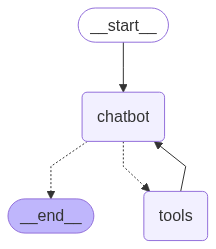

In [74]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [76]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break

        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

Assistant: I need more information. What would you like to know about LangGraph?
User: What do you know about LangGraph?
Assistant: 
Assistant: {"query": "LangGraph", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.ibm.com/think/topics/langgraph", "title": "What is LangGraph? - IBM", "content": "LangGraph, created by [LangChain](https://www.ibm.com/think/topics/langchain), is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize [large language models](https://www.ibm.com/think/topics/large-language-models) (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the [...] By using a graph-based architecture, LangGraph enables users to scale artificial intelligence workflows without slowing down or sacrificing efficiency. LangGrap

#### Add memory
doesnot remember the context of previous interaction, solves this problem through persistent checkpointing

In [77]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [78]:
graph = graph_builder.compile(checkpointer=memory)

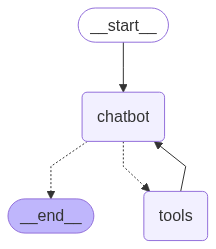

In [79]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [80]:
config = {"configurable": {"thread_id": "1"}}

In [81]:
user_input = "Hi there! My name is Will."

# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi there! My name is Will.
================================== Ai Message ==================================

Hi Will, nice to meet you! How can I help you today?


In [82]:
user_input = "Remember my name?"

# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Remember my name?
================================== Ai Message ==================================

Yes, your name is Will.


### Add human-in-the-loop controls

human-in-the-loop (HITL) functionality in LangGraph, which allows your chatbot or agent system to pause and wait for manual human input or approval during execution. This is useful for moderation, verification, or collaborative workflows.

In [87]:
# Add the human_assistance tool

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

# Define state schema
class State(TypedDict):
    messages: Annotated[list, add_messages]

# Build the state graph
graph_builder = StateGraph(State)


tool = TavilySearch(max_results=2)
tools = [tool]
llm_with_tools = llm.bind_tools(tools)

# Chatbot node (invokes the LLM)
def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    # Ensure only one tool is called to avoid parallel issues with interrupts
    assert len(message.tool_calls) <= 1
    return {"messages": [message]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

def human_assistance_node(state: State):
    query = "The assistant needs human help to proceed. Please respond."
    return interrupt({"query": query})

graph_builder.add_node("human_assistance", human_assistance_node)


 #Define routing: go to tool if tool_call exists, else go to human
def route_decision(state: State):
    last = state["messages"][-1]
    if hasattr(last, "tool_calls") and len(last.tool_calls) > 0:
        return "tools"
    if "human" in last.content.lower():
        return "human_assistance"
    return END

# Conditional routing based on LLM output
graph_builder.add_conditional_edges(
    "chatbot",
    route_decision,
    {
        "tools": "tools",
        "human_assistance": "human_assistance",
        END: END,
    }
)

# Normal flow: tools -> chatbot again
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge("human_assistance", "chatbot")
graph_builder.add_edge(START, "chatbot")

# Compile the graph
graph = graph_builder.compile()

In [88]:
memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)

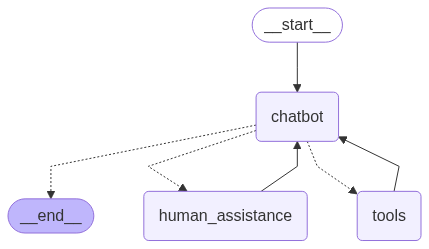

In [89]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
#  Prompt the chatbot
user_input = "I need some expert guidance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================

I can help you with that! What specific questions do you have about building an AI agent that you'd like expert guidance on? The more details you can provide, the better I can assist you. For example, what kind of AI agent are you trying to build, what are the key challenges you're facing, and what specific areas are you seeking advice on?


In [91]:
snapshot = graph.get_state(config)
snapshot.next
('tools',)

('tools',)

In [ ]:
#. Resume execution
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================

I can help you with that! What specific questions do you have about building an AI agent that you'd like expert guidance on? The more details you can provide, the better I can assist you. For example, what kind of AI agent are you trying to build, what are the key challenges you're facing, and what specific areas are you seeking advice on?
